# ERA5 reanalysis data.

- Check download info in this [notebook](/workspaces/BlueMath/toolkit/data/ERA5_DestinE_SingleLevels.ipynb)!
- Below, we load already processed data in a grid centered in Alexandria.

In [1]:
import xarray as xr

alexandria_waves_grid = xr.open_dataset("inputs/waves/ERA5_bulk_waves_2020.nc")
alexandria_waves_grid

<xarray.Dataset> Size: 2MB
Dimensions:     (valid_time: 8784, latitude: 4, longitude: 4)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23...
  * latitude    (latitude) float64 32B 32.0 31.5 31.0 30.5
  * longitude   (longitude) float64 32B 29.0 29.5 30.0 30.5
    meanSea     float64 8B ...
    number      int64 8B ...
Data variables:
    swh         (valid_time, latitude, longitude) float32 562kB ...
    pp1d        (valid_time, latitude, longitude) float32 562kB ...
    mwd         (valid_time, latitude, longitude) float32 562kB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-05-05T16:51 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [2]:
alexandria_waves_sites = alexandria_waves_grid.stack(
    site=["longitude", "latitude"], create_index=False
)
alexandria_waves_sites["site"] = [
    f"Lon: {lon} | Lat: {lat}"
    for lon, lat in zip(
        alexandria_waves_sites.longitude.values, alexandria_waves_sites.latitude.values
    )
]
alexandria_waves_sites

<xarray.Dataset> Size: 2MB
Dimensions:     (valid_time: 8784, site: 16)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23...
  * site        (site) <U21 1kB 'Lon: 29.0 | Lat: 32.0' ... 'Lon: 30.5 | Lat:...
    latitude    (site) float64 128B 32.0 31.5 31.0 30.5 ... 32.0 31.5 31.0 30.5
    longitude   (site) float64 128B 29.0 29.0 29.0 29.0 ... 30.5 30.5 30.5 30.5
    meanSea     float64 8B ...
    number      int64 8B ...
Data variables:
    swh         (valid_time, site) float32 562kB 1.022 0.9399 0.6978 ... nan nan
    pp1d        (valid_time, site) float32 562kB 6.52 6.859 6.957 ... nan nan
    mwd         (valid_time, site) float32 562kB 306.2 312.0 321.5 ... nan nan
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-05-05T16:51 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

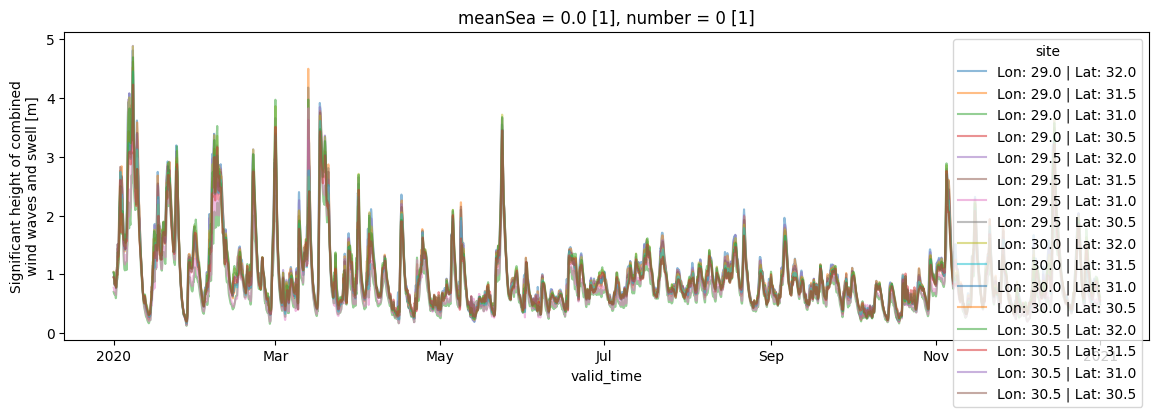

In [3]:
alexandria_waves_sites.swh.plot(figsize=(14, 4), hue="site", alpha=0.5)

# WHACS reanalysis data.

- Download can be performed using [CSIRO Data Access Portal](https://data.csiro.au/collection/csiro:64350).
- Below, we just load a processed month in a location next to Alexandria.

In [4]:
alexandria_spectra = xr.open_dataset("inputs/waves/WHACS_spectra_waves_202001.nc")
alexandria_spectra

<xarray.Dataset> Size: 5MB
Dimensions:   (time: 744, freq: 28, dir: 30)
Coordinates:
  * time      (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * freq      (freq) float64 224B 0.04118 0.0453 0.04983 ... 0.4908 0.5399
  * dir       (dir) float64 240B 84.0 72.0 60.0 48.0 ... 132.0 120.0 108.0 96.0
    seapoint  int32 4B ...
Data variables:
    efth      (time, freq, dir) float64 5MB ...

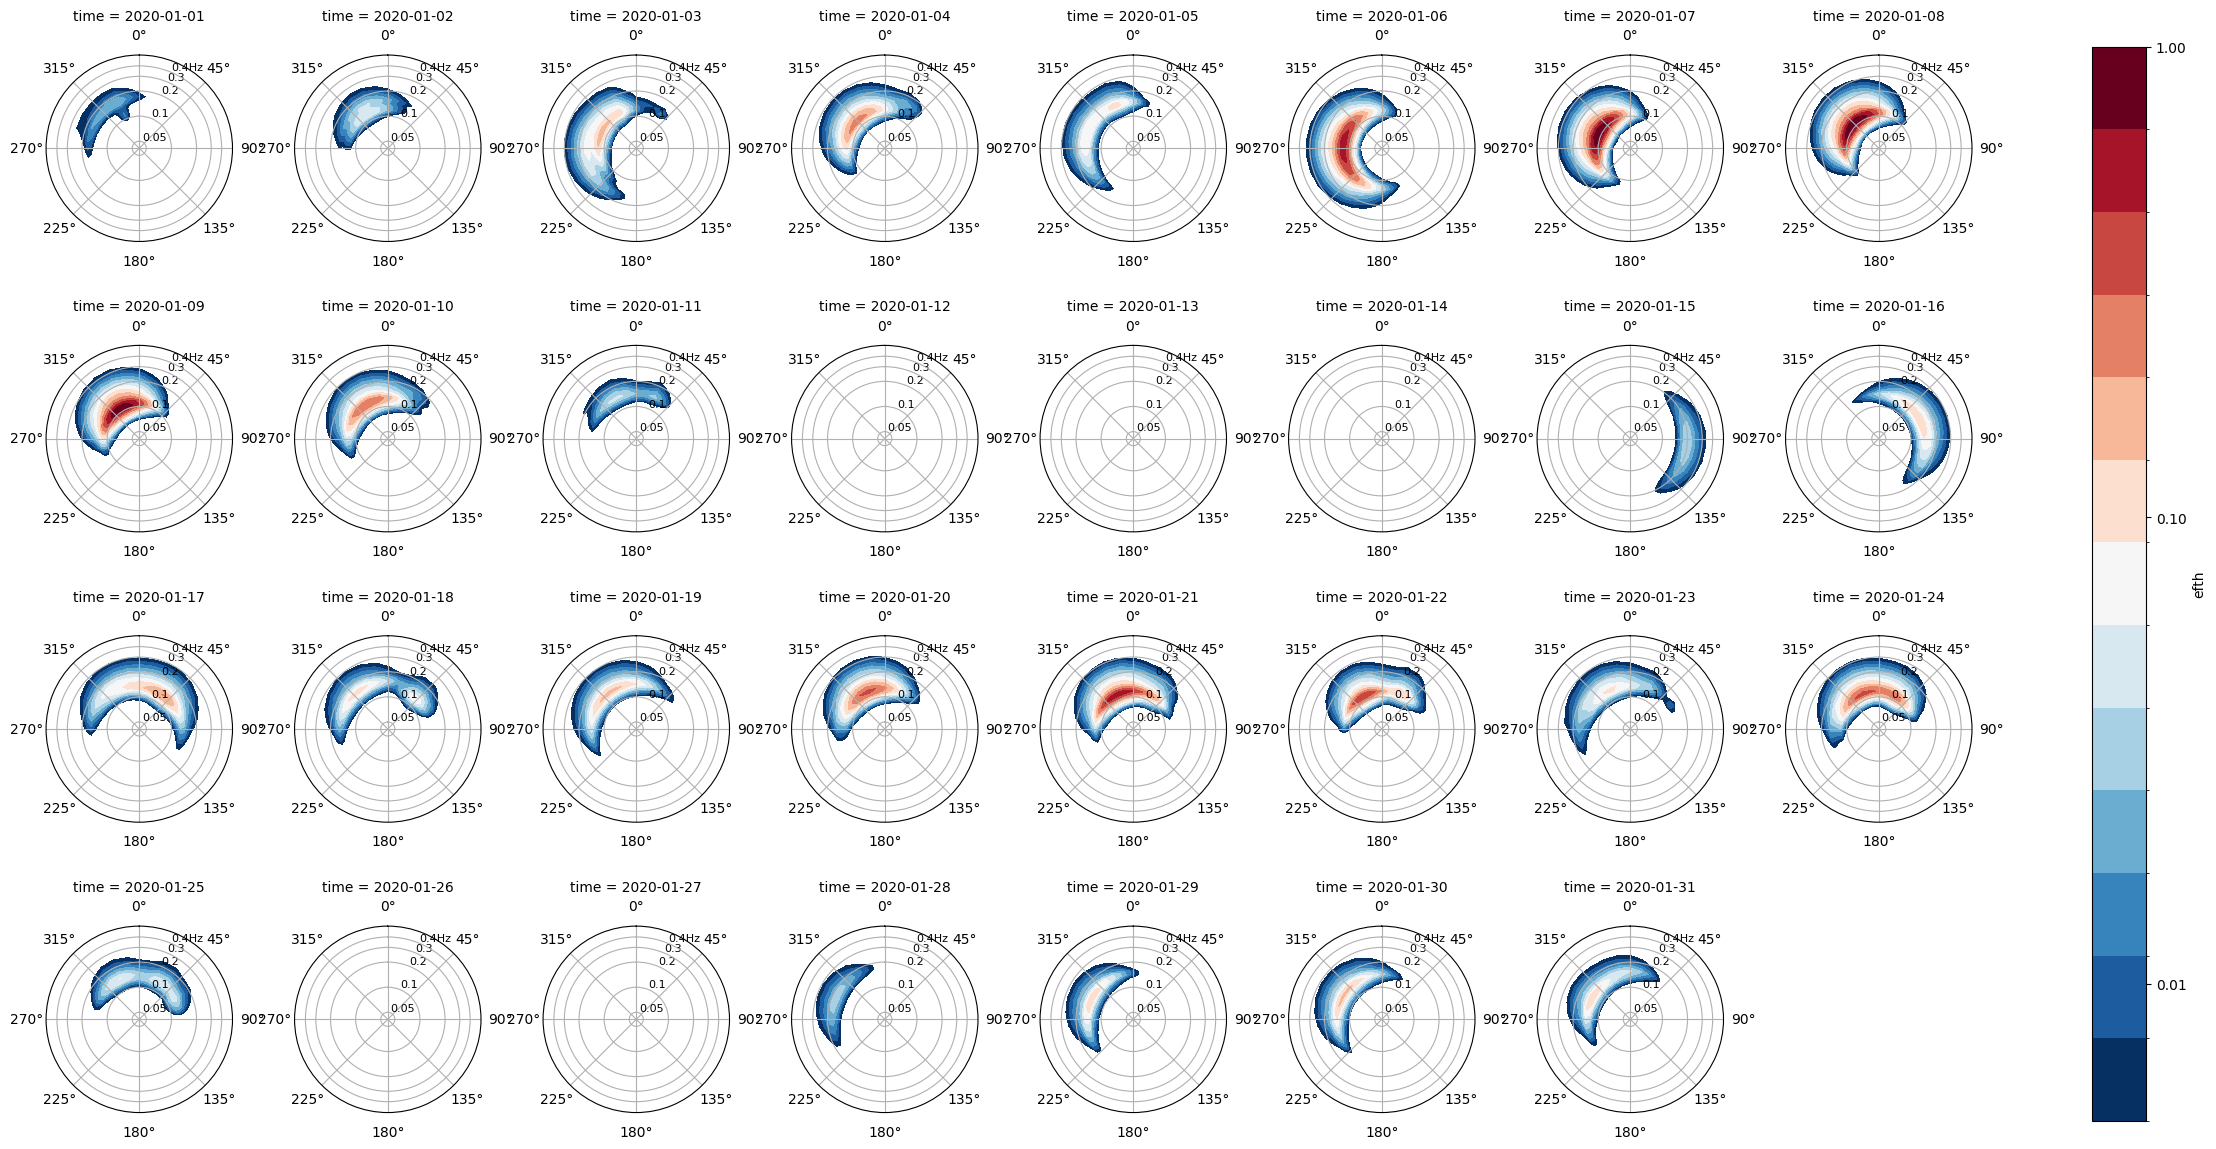

In [5]:
alexandria_spectra.efth.resample(time="1D").mean().spec.plot(col="time", col_wrap=8)

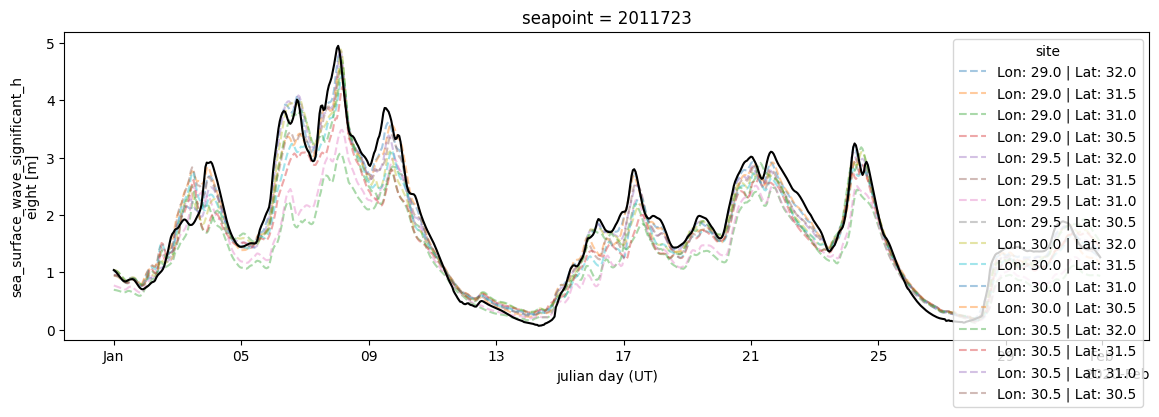

In [6]:
# Compare ERA5 with WHACS

alexandria_waves_sites.sel(valid_time="2020-01").swh.plot(
    hue="site", figsize=(14, 4), alpha=0.4, ls="--"
)
alexandria_spectra.spec.hs().plot(c="black", label="WHACS")